In [2]:
from google.colab import files
uploaded = files.upload()   # a file picker appears; choose heart.csv

Saving heart.csv to heart.csv


# Heart Disease Analysis (Exploratory Data Analysis)

**Goal:** Find out which patient characteristics are most associated with heart disease in a clinical dataset of 918 patients.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Questions I want to answer:**
1. Is the data clean enough to trust?
2. Which patient characteristics separate patients with heart disease from those without?
3. How strong and how reliable are those patterns?

In [5]:
df = pd.read_csv("heart.csv")
print(df.shape)
print(df.columns.tolist())

(918, 12)
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("heart.csv")
print(df.shape)
df.head()

(918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Dataset

Source: Kaggle, "Heart Failure Prediction Dataset" (fedesoriano). 918 rows, 12 columns. Each row is one patient.

| Column | Meaning |
|---|---|
| Age | Age in years |
| Sex | M / F |
| ChestPainType | TA = typical angina, ATA = atypical angina, NAP = non-anginal pain, ASY = asymptomatic |
| RestingBP | Resting blood pressure (mm Hg) |
| Cholesterol | Serum cholesterol (mg/dl) |
| FastingBS | 1 if fasting blood sugar > 120 mg/dl, else 0 |
| RestingECG | Resting ECG result: Normal, ST (ST-T abnormality), LVH (left ventricular hypertrophy) |
| MaxHR | Maximum heart rate achieved |
| ExerciseAngina | Exercise-induced angina: Y / N |
| Oldpeak | ST depression during exercise vs rest |
| ST_Slope | Slope of the peak-exercise ST segment: Up, Flat, Down |
| HeartDisease | **Target.** 1 = heart disease, 0 = no heart disease |

In [7]:
df.info()
display(df.describe().T)
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


**What I notice:**
- 918 rows, 12 columns, no null values, and the data types look right.
- `RestingBP` has a minimum of 0 and `Cholesterol` has a minimum of 0. Neither is physiologically possible, so these need investigating.
- `Oldpeak` has a minimum of -2.6. Negative values can be valid for ST depression, so I will check them, not delete them.

In [8]:
rename_map = {
    "age": "Age", "sex": "Sex", "cp": "ChestPainType", "trestbps": "RestingBP",
    "chol": "Cholesterol", "fbs": "FastingBS", "restecg": "RestingECG",
    "thalach": "MaxHR", "exang": "ExerciseAngina", "oldpeak": "Oldpeak",
    "slope": "ST_Slope", "target": "HeartDisease",
}
df = df.rename(columns=rename_map)

# make Sex readable if it is numeric
if pd.api.types.is_numeric_dtype(df["Sex"]):
    df["Sex"] = df["Sex"].map({1: "M", 0: "F"})

print(df.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


## 2. Data Quality Checks

`isnull()` only catches values that are literally empty. It cannot catch impossible values entered as 0, so I check four things:
1. Missing values
2. Duplicate rows
3. Impossible zeros in `Cholesterol` and `RestingBP`
4. Class balance of the target

In [9]:
print("Missing values:\n", df.isnull().sum(), "\n")
print("Duplicate rows:", df.duplicated().sum())
print("Zero cholesterol:", (df["Cholesterol"] == 0).sum())
print("Zero resting BP:", (df["RestingBP"] == 0).sum())
print("Target balance:\n", df["HeartDisease"].value_counts(normalize=True).round(3))

Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64 

Duplicate rows: 0
Zero cholesterol: 172
Zero resting BP: 1
Target balance:
 HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64


**Results:**
- Missing values: none. Duplicate rows: none.
- **172 rows (18.7%) have Cholesterol = 0** and 1 row has RestingBP = 0. These are impossible values hiding in columns that have no nulls.
- Target balance: 55.3% have heart disease, 44.7% do not. This is balanced enough that no resampling is needed.

## 3. Data Cleaning

### 3.1 Resting blood pressure of 0
Only one row has this impossible value, so I drop it. The loss is negligible.

### 3.2 Are the zero-cholesterol rows random?

Before deciding how to handle them, I flag them (without changing any values yet) and check whether those rows look like everyone else.

In [10]:
df["Chol_zero"] = (df["Cholesterol"] == 0)
print(df.groupby("Chol_zero")["HeartDisease"].agg(["count", "mean"]).round(3))
print(df[df["Chol_zero"]]["ChestPainType"].value_counts())

           count   mean
Chol_zero              
False        746  0.477
True         172  0.884
ChestPainType
ASY    126
NAP     34
ATA      7
TA       5
Name: count, dtype: int64


**Result:**

| Group | Rows | Disease rate |
|---|---|---|
| Cholesterol recorded properly | 746 | 47.7% |
| Cholesterol = 0 | 171 | 88.3% |

74% of the zero-cholesterol patients (126 of 171) also have asymptomatic (ASY) chest pain. So these rows are **not random**: they are concentrated in a specific kind of patient with a much higher disease rate.

My hypothesis is that different source hospitals recorded "not measured" as 0, but I cannot confirm that from the file alone.

**Decision:** replacing the zeros with the median would hide this pattern and invent data for almost 1 in 5 patients. So I treat them as missing and exclude them from cholesterol-specific analysis only.

In [11]:
rows_before = len(df)

# 1. Cholesterol: flag the zeros, then treat them as missing (do NOT impute)
df["Chol_missing"] = (df["Cholesterol"] == 0).astype(int)
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
print("Valid cholesterol values:", df["Cholesterol"].notna().sum())

# 2. RestingBP: one impossible row, drop it
print(df[df["RestingBP"] == 0])
df = df[df["RestingBP"] != 0].reset_index(drop=True)

# 3. Oldpeak negatives: check, keep
print("Negative Oldpeak rows:", (df["Oldpeak"] < 0).sum())

print("Rows before:", rows_before, "| after:", len(df))

Valid cholesterol values: 746
     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
449   55   M           NAP          0          NaN          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  Chol_zero  \
449    155              N      1.5     Flat             1       True   

     Chol_missing  
449             1  
Negative Oldpeak rows: 13
Rows before: 918 | after: 917


### 3.3 Cleaning decisions

| Issue | Rows | What I did | Why |
|---|---|---|---|
| Missing values | 0 | Nothing | None found |
| Duplicates | 0 | Nothing | None found |
| RestingBP = 0 | 1 | Dropped the row | A single impossible value; negligible loss |
| Cholesterol = 0 | 172 in the original data (171 after the row above was dropped) | Set to NaN, kept a `Chol_missing` flag | Not random (see 3.2); imputing would distort the data |
| Oldpeak < 0 | 13 | Kept | Negative ST depression can be a valid reading |

**Final dataset: 917 rows** (746 with valid cholesterol).

In [12]:
df = df.drop(columns=["Chol_zero"])

print("Final rows:", len(df))
print(df.groupby("Chol_missing")["HeartDisease"].agg(["count", "mean"]).round(3))

Final rows: 917
              count   mean
Chol_missing              
0               746  0.477
1               171  0.883


## 4. Exploratory Data Analysis

For each question below I show the numbers and a chart, then state what it means. Disease rate = the share of patients in a group with HeartDisease = 1.

Overall disease rate: 55.3%


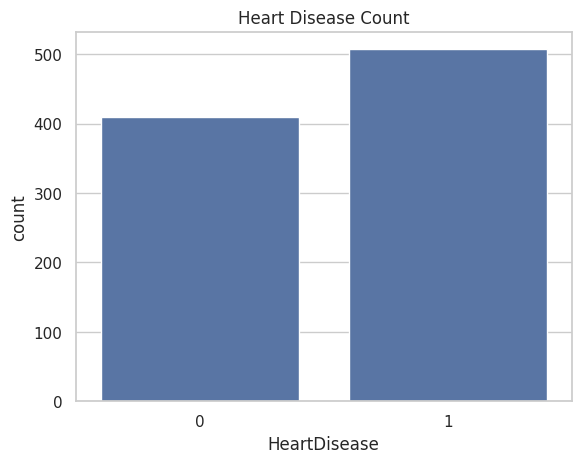

In [13]:
rate = df["HeartDisease"].mean() * 100
print(f"Overall disease rate: {rate:.1f}%")
sns.countplot(x="HeartDisease", data=df)
plt.title("Heart Disease Count"); plt.show()

**Overall:** 55.3% of the 917 patients have heart disease. This is a clinical sample of people tested for heart problems, so it is not the prevalence in the general population.

          count  rate
ST_Slope             
Down         63  77.8
Flat        459  82.8
Up          395  19.7


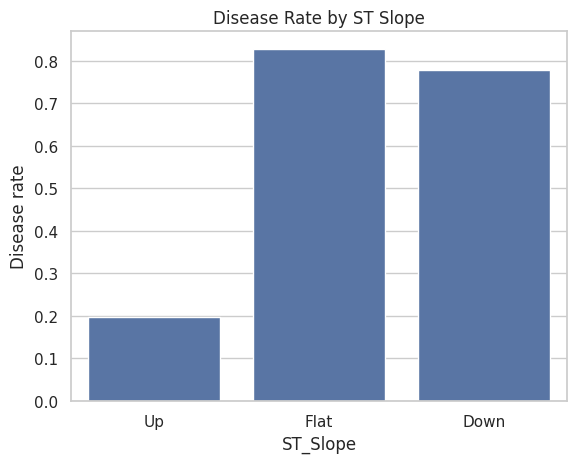

In [28]:
# 4.2 ST_Slope
s = df.groupby("ST_Slope")["HeartDisease"].agg(count="count", rate="mean")
s["rate"] = (s["rate"] * 100).round(1)
print(s)
sns.barplot(x="ST_Slope", y="HeartDisease", data=df, errorbar=None, order=["Up", "Flat", "Down"])
plt.ylabel("Disease rate")
plt.title("Disease Rate by ST Slope")
plt.show()

**ST_Slope is the strongest separator.** Disease rate is 19.7% with an upsloping ST segment (n = 395), versus 82.8% with a flat one (n = 459) and 77.8% with a downsloping one (n = 63). The Down group is small, so I treat Flat and Down together as "not Up".

Sex
F    25.9
M    63.1
Name: HeartDisease, dtype: float64


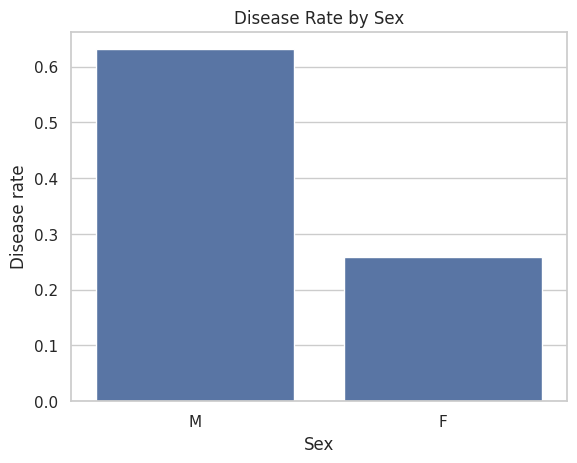

In [14]:
print((df.groupby("Sex")["HeartDisease"].mean() * 100).round(1))
sns.barplot(x="Sex", y="HeartDisease", data=df, errorbar=None)
plt.ylabel("Disease rate"); plt.title("Disease Rate by Sex"); plt.show()

**Sex:** disease rate is 63.1% for men (n = 724) vs 25.9% for women (n = 193). The sample is 79% male, so the female estimate rests on a small group and I do not generalize this to men and women overall.

ChestPainType
ASY    79.0
ATA    13.9
NAP    35.1
TA     43.5
Name: HeartDisease, dtype: float64


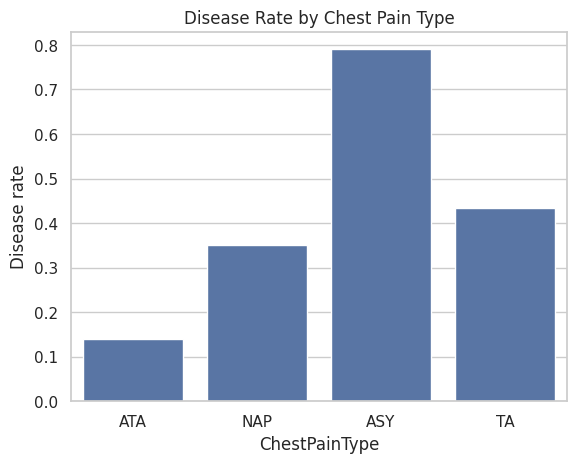

In [15]:
print((df.groupby("ChestPainType")["HeartDisease"].mean() * 100).round(1))
sns.barplot(x="ChestPainType", y="HeartDisease", data=df, errorbar=None)
plt.ylabel("Disease rate"); plt.title("Disease Rate by Chest Pain Type"); plt.show()

**Asymptomatic (ASY) patients have the highest disease rate: 79.0%** (n = 496), versus 13.9% for atypical angina (n = 173). This is counterintuitive: patients reporting no chest pain are the highest-risk group in this sample, which suggests reported symptoms alone are a poor signal here. (The TA group has only 46 patients, so I draw no conclusions from it.)

              mean  median
HeartDisease              
0             50.6    51.0
1             55.9    57.0


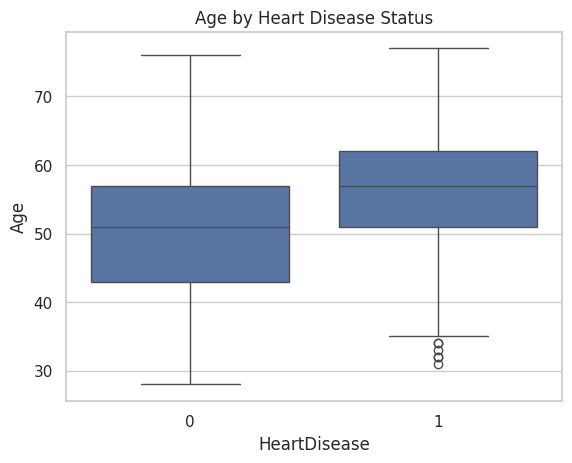

In [16]:
print(df.groupby("HeartDisease")["Age"].agg(["mean", "median"]).round(1))
sns.boxplot(x="HeartDisease", y="Age", data=df)
plt.title("Age by Heart Disease Status"); plt.show()

**Age:** mean 55.9 (disease) vs 50.6 (no disease). Older patients have more disease, as expected, but the gap is modest compared with the variables above.

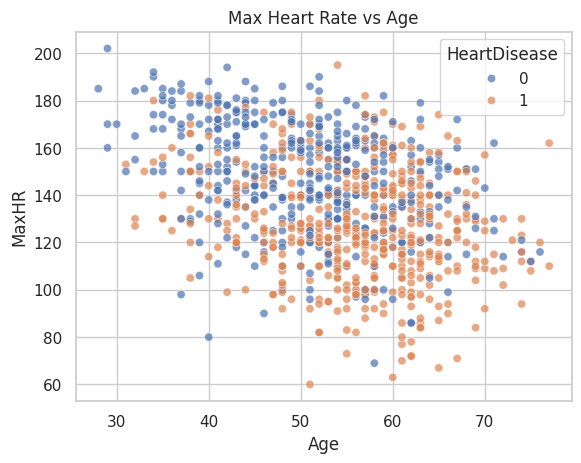

HeartDisease
0    148.2
1    127.6
Name: MaxHR, dtype: float64


In [17]:
sns.scatterplot(x="Age", y="MaxHR", hue="HeartDisease", data=df, alpha=0.7)
plt.title("Max Heart Rate vs Age"); plt.show()
print(df.groupby("HeartDisease")["MaxHR"].mean().round(1))

**Max heart rate:** patients with disease averaged 127.6 bpm vs 148.2 bpm without, about 20 bpm lower.

The disease group is also older (mean 55.9 vs 50.6), and max heart rate falls with age, so I checked whether age explains the gap. It does not: disease patients had lower MaxHR in **every age band** (n = 196, 315, 324, 82 for <=45, 46-55, 56-65, 66+), by about 17, 19, 14 and 12 bpm. The gap narrows in the older bands, so age explains a small part of it.

               mean  median
HeartDisease               
0             238.8   231.5
1             251.1   246.0


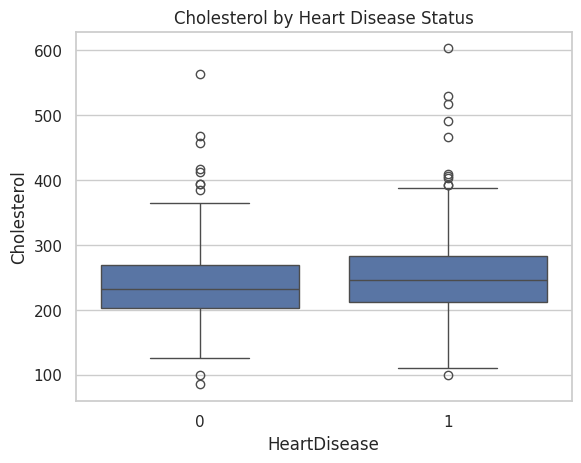

In [19]:
print(df.groupby("HeartDisease")["Cholesterol"].agg(["mean", "median"]).round(1))
sns.boxplot(x="HeartDisease", y="Cholesterol", data=df)
plt.title("Cholesterol by Heart Disease Status"); plt.show()

**Cholesterol barely separates the groups:** median 246.0 (disease) vs 231.5 (no disease), about 15 mg/dl apart, using the 746 rows with valid values. That subset has a lower disease rate than the full dataset (47.7% vs 55.3%), so this comparison covers a healthier-than-average slice.

ExerciseAngina
N    35.0
Y    85.2
Name: HeartDisease, dtype: float64


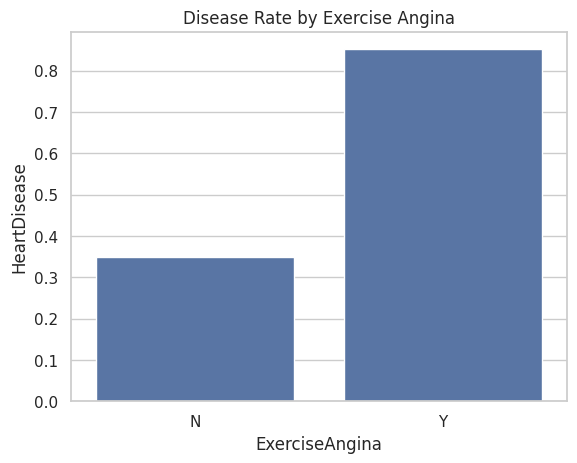

In [20]:
print((df.groupby("ExerciseAngina")["HeartDisease"].mean() * 100).round(1))
sns.barplot(x="ExerciseAngina", y="HeartDisease", data=df, errorbar=None)
plt.title("Disease Rate by Exercise Angina"); plt.show()

**Exercise-induced angina:** 85.2% disease rate with angina (n = 371) vs 35.0% without (n = 546). A 50-point gap from a single yes/no variable.

In [21]:
print("5.1 Overall disease rate: %.1f%% (n=%d)" % (df["HeartDisease"].mean()*100, len(df)))

print("\n5.2 Disease rate by Sex (%):")
print((df.groupby("Sex")["HeartDisease"].mean()*100).round(1))

print("\n5.3 Disease rate by ChestPainType (%):")
print((df.groupby("ChestPainType")["HeartDisease"].mean()*100).round(1))

print("\n5.4 Age by HeartDisease:")
print(df.groupby("HeartDisease")["Age"].agg(["mean","median"]).round(1))

print("\n5.5 MaxHR by HeartDisease:")
print(df.groupby("HeartDisease")["MaxHR"].agg(["mean","median"]).round(1))

print("\n5.6 Cholesterol by HeartDisease (valid only):")
valid = df[df["Cholesterol"].notna()]
print(valid.groupby("HeartDisease")["Cholesterol"].agg(["count","mean","median"]).round(1))

print("\n5.7 Disease rate by ExerciseAngina (%):")
print((df.groupby("ExerciseAngina")["HeartDisease"].mean()*100).round(1))

print("\n5.8 Disease rate by ST_Slope (%):")
print((df.groupby("ST_Slope")["HeartDisease"].mean()*100).round(1))

5.1 Overall disease rate: 55.3% (n=917)

5.2 Disease rate by Sex (%):
Sex
F    25.9
M    63.1
Name: HeartDisease, dtype: float64

5.3 Disease rate by ChestPainType (%):
ChestPainType
ASY    79.0
ATA    13.9
NAP    35.1
TA     43.5
Name: HeartDisease, dtype: float64

5.4 Age by HeartDisease:
              mean  median
HeartDisease              
0             50.6    51.0
1             55.9    57.0

5.5 MaxHR by HeartDisease:
               mean  median
HeartDisease               
0             148.2   150.0
1             127.6   126.0

5.6 Cholesterol by HeartDisease (valid only):
              count   mean  median
HeartDisease                      
0               390  238.8   231.5
1               356  251.1   246.0

5.7 Disease rate by ExerciseAngina (%):
ExerciseAngina
N    35.0
Y    85.2
Name: HeartDisease, dtype: float64

5.8 Disease rate by ST_Slope (%):
ST_Slope
Down    77.8
Flat    82.8
Up      19.7
Name: HeartDisease, dtype: float64


In [22]:
for col in ["Sex", "ChestPainType", "ExerciseAngina", "ST_Slope"]:
    print(f"\n{col}:")
    print(df[col].value_counts())

df["AgeBand"] = pd.cut(df["Age"], bins=[0, 45, 55, 65, 100], labels=["<=45", "46-55", "56-65", "66+"])
print("\nMean MaxHR by AgeBand and HeartDisease:")
print(df.groupby(["AgeBand", "HeartDisease"], observed=True)["MaxHR"].mean().unstack().round(1))


Sex:
Sex
M    724
F    193
Name: count, dtype: int64

ChestPainType:
ChestPainType
ASY    496
NAP    202
ATA    173
TA      46
Name: count, dtype: int64

ExerciseAngina:
ExerciseAngina
N    546
Y    371
Name: count, dtype: int64

ST_Slope:
ST_Slope
Flat    459
Up      395
Down     63
Name: count, dtype: int64

Mean MaxHR by AgeBand and HeartDisease:
HeartDisease      0      1
AgeBand                   
<=45          158.9  141.7
46-55         146.8  127.9
56-65         138.7  125.1
66+           133.9  121.8


In [23]:
print(df["AgeBand"].value_counts().sort_index())

AgeBand
<=45     196
46-55    315
56-65    324
66+       82
Name: count, dtype: int64


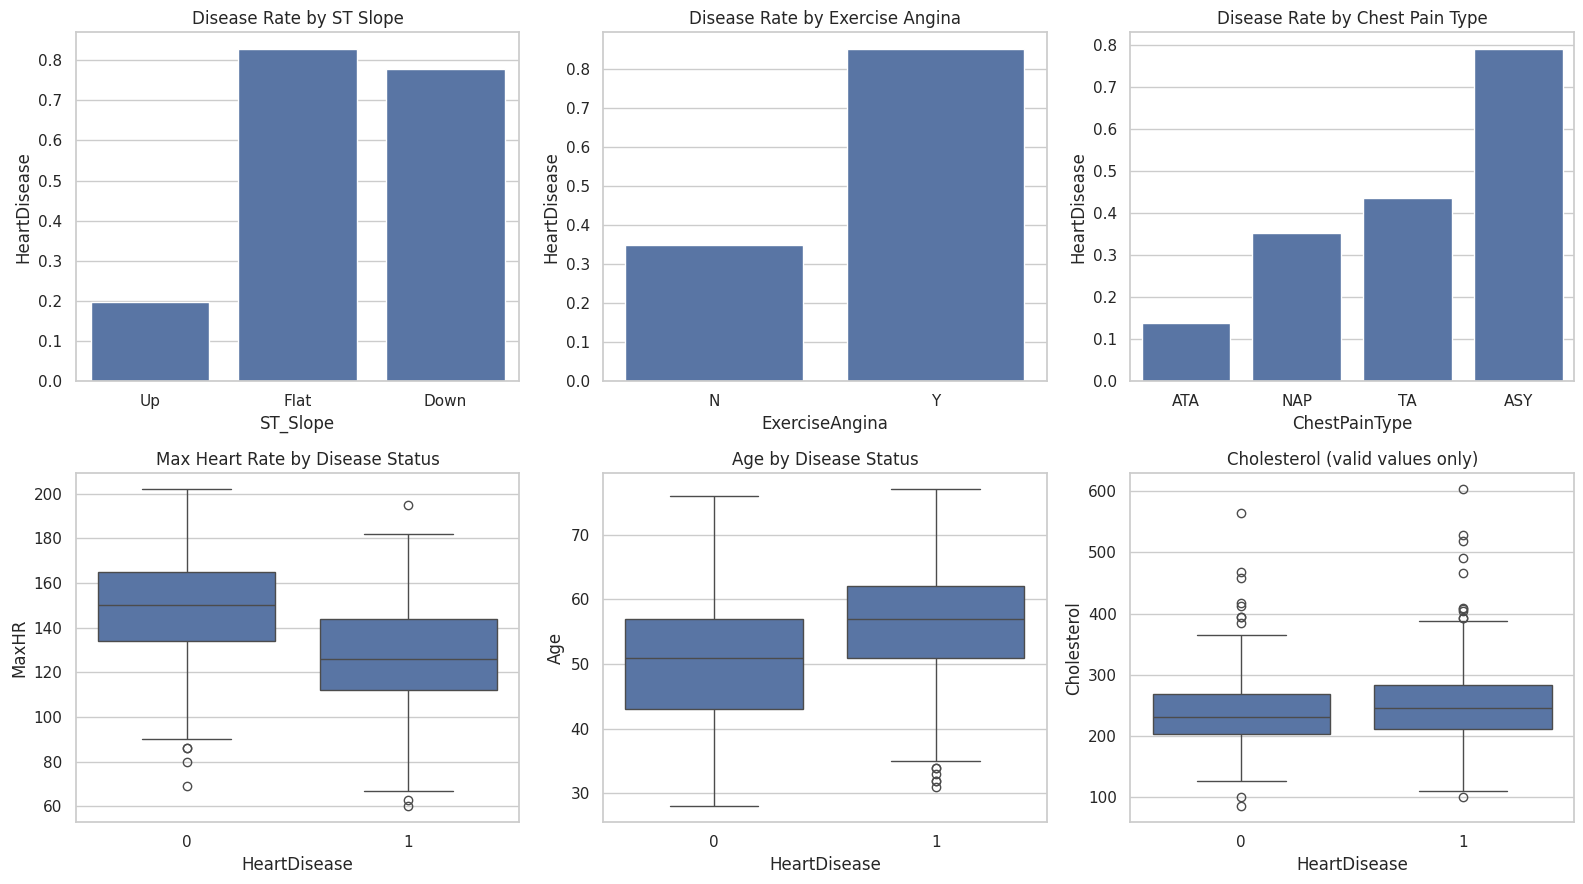

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.barplot(x="ST_Slope", y="HeartDisease", data=df, errorbar=None, ax=axes[0,0], order=["Up","Flat","Down"])
axes[0,0].set_title("Disease Rate by ST Slope")

sns.barplot(x="ExerciseAngina", y="HeartDisease", data=df, errorbar=None, ax=axes[0,1])
axes[0,1].set_title("Disease Rate by Exercise Angina")

sns.barplot(x="ChestPainType", y="HeartDisease", data=df, errorbar=None, ax=axes[0,2], order=["ATA","NAP","TA","ASY"])
axes[0,2].set_title("Disease Rate by Chest Pain Type")

sns.boxplot(x="HeartDisease", y="MaxHR", data=df, ax=axes[1,0])
axes[1,0].set_title("Max Heart Rate by Disease Status")

sns.boxplot(x="HeartDisease", y="Age", data=df, ax=axes[1,1])
axes[1,1].set_title("Age by Disease Status")

sns.boxplot(x="HeartDisease", y="Cholesterol", data=df[df["Cholesterol"].notna()], ax=axes[1,2])
axes[1,2].set_title("Cholesterol (valid values only)")

plt.tight_layout()
plt.savefig("eda_summary.png", dpi=150)
plt.show()

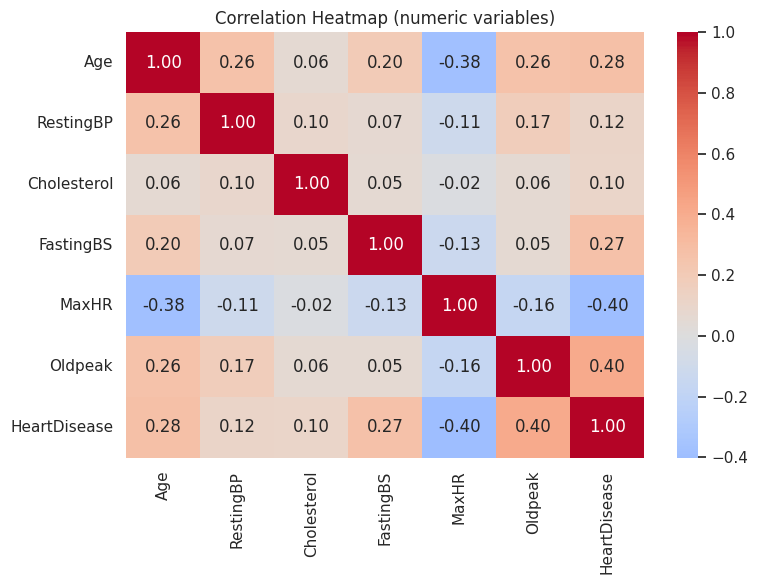

Oldpeak        0.40
MaxHR         -0.40
Age            0.28
FastingBS      0.27
RestingBP      0.12
Cholesterol    0.10
Name: HeartDisease, dtype: float64


In [25]:
num_df = df.select_dtypes(include="number").drop(columns=["Chol_missing"])
corr = num_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric variables)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

print(corr["HeartDisease"].drop("HeartDisease").sort_values(key=abs, ascending=False).round(2))

**What the heatmap shows:** Oldpeak (r = 0.40) and MaxHR (r = -0.40) have the strongest correlations with heart disease: higher ST depression and lower max heart rate go with disease. Age (0.28) and FastingBS (0.27) are weaker positive correlations, while RestingBP (0.12) and Cholesterol (0.10) are close to unrelated to the outcome.

**Caveat:** No numeric variable passes |r| = 0.40, so no single measurement dominates. The heatmap also only includes numeric variables, and my strongest findings (ST_Slope, ExerciseAngina, ChestPainType) are categorical and do not appear here. The cholesterol correlation uses only the 746 valid rows. Correlation does not imply causation.

## 6. Key Findings

1. Overall disease rate was 55.3% (n = 917), a clinical sample, not population prevalence.
2. ST_Slope was the strongest separator: 19.7% with Up vs 82.8% with Flat.
3. Exercise-induced angina: 85.2% disease rate vs 35.0% without.
4. Asymptomatic chest pain had the highest disease rate (79.0%) vs 13.9% for ATA, so reported symptoms alone look like a poor signal here.
5. Patients with disease had lower max heart rate (127.6 vs 148.2 bpm), and the gap held within every age band.
6. Cholesterol differed only slightly (median 246.0 vs 231.5, valid rows only).

## 7. Limitations

- Single, mostly male clinical sample (724 M, 193 F); results do not generalize.
- Observational data shows association, not causation.
- 18.7% of cholesterol values were missing in a non-random way, so cholesterol results cover a subset with a lower disease rate than the full data.
- Small groups: TA chest pain (n = 46) and downsloping ST segment (n = 63).
- No significance tests or predictive model were built.